## **I. Libraries and Data**

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Dataset: 25 points, highly dispersed
areas = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290]
prices = [200 + random.randint(-50, 50) for _ in areas]  # Base: ~3*area + 50 + noise
# Adjust to be linear but dispersed: prices[i] ≈ 3*areas[i] + 50 + noise
for i in range(len(areas)):
    prices[i] = 3 * areas[i] + 50 + random.randint(-50, 50)

# Print dataset
print("Dataset:")
for a, p in zip(areas, prices):
    print(f"Area: {a}m², Price: {p}k USD")


Dataset:
Area: 50m², Price: 244k USD
Area: 60m², Price: 186k USD
Area: 70m², Price: 288k USD
Area: 80m², Price: 314k USD
Area: 90m², Price: 352k USD
Area: 100m², Price: 378k USD
Area: 110m², Price: 427k USD
Area: 120m², Price: 448k USD
Area: 130m², Price: 404k USD
Area: 140m², Price: 485k USD
Area: 150m², Price: 529k USD
Area: 160m², Price: 503k USD
Area: 170m², Price: 552k USD
Area: 180m², Price: 628k USD
Area: 190m², Price: 600k USD
Area: 200m², Price: 677k USD
Area: 210m², Price: 728k USD
Area: 220m², Price: 676k USD
Area: 230m², Price: 721k USD
Area: 240m², Price: 817k USD
Area: 250m², Price: 842k USD
Area: 260m², Price: 877k USD
Area: 270m², Price: 867k USD
Area: 280m², Price: 867k USD
Area: 290m², Price: 875k USD


## **II. Function Building for Gradient Descent**

In [3]:
def predict(area, w1, w0):
    return w1 * area + w0

In [4]:
def mean_absolute_error(y_true, y_pred):
    """
    Calculate Mean Absolute Error (MAE)
    Args:
        y_true: Actual values (numpy array or list)
        y_pred: Predicted values (numpy array or list)
    Returns:
        MAE: Mean of the absolute values of errors
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    """
    Calculate Root Mean Squared Error (RMSE)
    Args:
        y_true: Actual values (numpy array or list)
        y_pred: Predicted values (numpy array or list)
    Returns:
        RMSE: Square root of the mean squared errors
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r_squared(y_true, y_pred):
    """
    Calculate R-squared (R²)
    Args:
        y_true: Actual values (numpy array or list)
        y_pred: Predicted values (numpy array or list)
    Returns:
        R²: Coefficient of determination, measures model goodness-of-fit
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

def evaluate_regression(y_true, y_pred):
    """
    Calculate all metrics: MAE, RMSE, R²
    Args:
        y_true: Actual values (numpy array or list)
        y_pred: Predicted values (numpy array or list)
    Returns:
        Dictionary containing MAE, RMSE, R² metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r_squared(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

def mse(areas, prices, w1, w0):
    n = len(areas)
    total_error = 0
    for i in range(n):
        y_hat = predict(areas[i], w1, w0)
        total_error += (prices[i] - y_hat) ** 2
    return total_error / n


## **III. Raw check with Initial Data**

Initial MSE: 371823.48


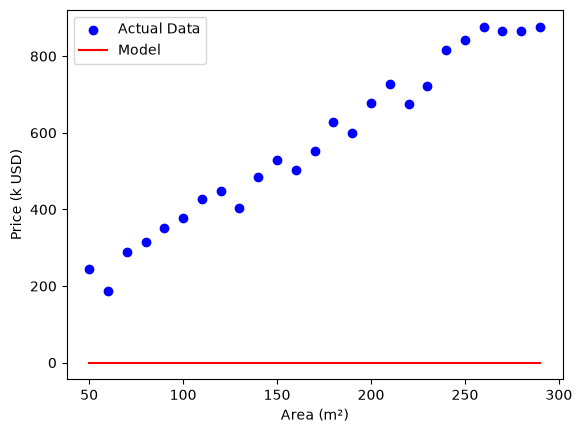

In [5]:
# Test with w1=0, w0=0 → High MSE
print("Initial MSE:", mse(areas, prices, 0, 0))

# Visualization
plt.scatter(areas, prices, color='blue', label='Actual Data')
preds = [predict(a, 0, 0) for a in areas]
plt.plot(areas, preds, color='red', label='Model')
plt.xlabel('Area (m²)')
plt.ylabel('Price (k USD)')
plt.legend()
plt.show()

In [6]:
w1, w0 = 0, 0
print("Initial MSE:", mse(areas, prices, w1, w0))
# Predict with the trained model
y_pred = [predict(a, w1, w0) for a in areas]

# Evaluate the model
metrics = evaluate_regression(prices, y_pred)
print("\nModel evaluation results after training:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


Initial MSE: 371823.48

Model evaluation results after training:
MAE: 571.4000
RMSE: 609.7733
R²: -7.2034


## **IV. Gradient Descent**

In [7]:
def gradient_descent(areas, prices, w1_init=0, w0_init=0, alpha=0.000001, epochs=1000):
    n = len(areas)
    w1, w0 = w1_init, w0_init
    losses = []

    for epoch in range(epochs):
        dw1, dw0 = 0, 0
        for i in range(n):
            y_hat = predict(areas[i], w1, w0)
            dw1 += -2 * (prices[i] - y_hat) * areas[i] / n #derivative of MSE with respect to w1
            dw0 += -2 * (prices[i] - y_hat) / n #derivative of MSE with respect to w0
        w1 -= alpha * dw1 #learning rate * gradient to optimize w1
        w0 -= alpha * dw0 #learning rate * gradient to optimize w0
        loss = mse(areas, prices, w1, w0)
        losses.append(loss)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: w1={w1:.2f}, w0={w0:.2f}, Loss={loss:.2f}")

    return w1, w0, losses

Epoch 0: w1=0.22, w0=0.00, Loss=323079.58
Epoch 100: w1=3.29, w0=0.02, Loss=1856.36
Epoch 200: w1=3.29, w0=0.02, Loss=1856.07
Epoch 300: w1=3.29, w0=0.02, Loss=1856.02
Epoch 400: w1=3.29, w0=0.03, Loss=1855.97
Epoch 500: w1=3.29, w0=0.03, Loss=1855.91
Epoch 600: w1=3.29, w0=0.03, Loss=1855.86
Epoch 700: w1=3.29, w0=0.03, Loss=1855.81
Epoch 800: w1=3.29, w0=0.03, Loss=1855.76
Epoch 900: w1=3.29, w0=0.04, Loss=1855.70


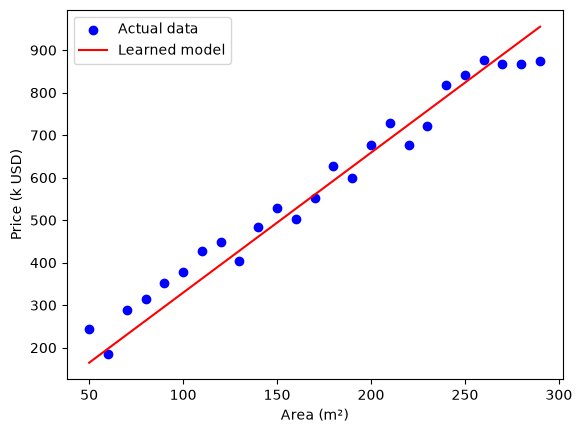

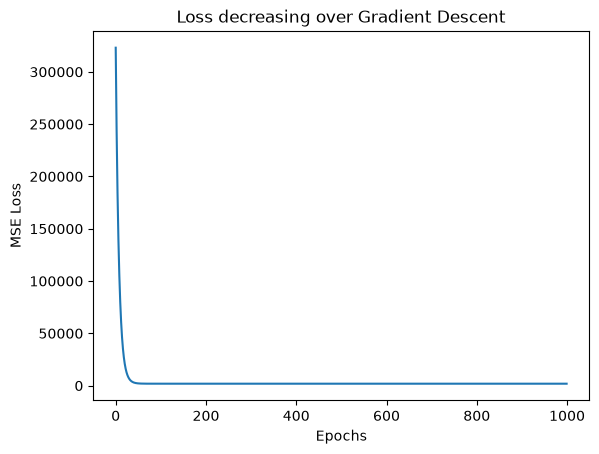

In [8]:
# Run Gradient Descent
w1, w0, losses = gradient_descent(areas, prices)

# Visualize final model
plt.scatter(areas, prices, color='blue', label='Actual data')
preds = [predict(a, w1, w0) for a in areas]
plt.plot(areas, preds, color='red', label='Learned model')
plt.xlabel('Area (m²)')
plt.ylabel('Price (k USD)')
plt.legend()
plt.show()

# Loss curve
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Loss decreasing over Gradient Descent')
plt.show()

In [9]:
# Predict with the trained model
y_pred = [predict(a, w1, w0) for a in areas]

# Evaluate the model
metrics = evaluate_regression(prices, y_pred)
print("\nModel evaluation results after training:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")



Model evaluation results after training:
MAE: 38.3755
RMSE: 43.0773
R²: 0.9591
